<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/LSTM_%D0%B4%D0%BB%D1%8F_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
# Створюємо змінну типу numpy.ndarray з кількості пасажирів у форматі float32
data = df['Passengers'].values.astype('float32')

# Перевіримо тип і перші 5 значень
print(type(data))
print(data[:5])

<class 'numpy.ndarray'>
[112. 118. 132. 129. 121.]


Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [3]:
# Визначимо розмір тренувальної вибірки 67% від усіх даних
train_size = int(len(data) * 0.67)

# Розділимо дані послідовно
train, val = data[:train_size], data[train_size:]

# Перевіримо розміри та кілька перших елементів
print(f"Train size: {len(train)}, Validation size: {len(val)}")
print("Train sample:", train[:5])
print("Validation sample:", val[:5])

Train size: 96, Validation size: 48
Train sample: [112. 118. 132. 129. 121.]
Validation sample: [315. 301. 356. 348. 355.]


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [5]:
def create_dataset(dataset, lookback):

    X, y = [], []

    # Формуємо вікна
    for i in range(len(dataset) - lookback):
        # Беремо lookback попередніх значень
        window = dataset[i:(i + lookback)]
        # Ціль - наступне після вікна значення
        target = dataset[i + lookback]

        X.append(window)
        y.append(target)

    # Перетворимо у тензори PyTorch з форматом (batch_size, seq_len, input_dim)
    X = torch.tensor(X).unsqueeze(-1)
    y = torch.tensor(y).unsqueeze(-1)

    return X, y

In [6]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(val, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1, 1]) torch.Size([95, 1])
torch.Size([47, 1, 1]) torch.Size([47, 1])


/tmp/ipython-input-1676296439.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X).unsqueeze(-1)


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [7]:
class AirModel(nn.Module):

    def __init__(self, hidden_size=50, num_layers=1, input_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)  # прогноз однієї точки

    def forward(self, x):

        if x.dim() == 2:
            x = x.unsqueeze(-1)

        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_size)
        last = out[:, -1, :]            # беремо останній часовий крок: (batch, hidden_size)
        pred = self.fc(last)            # -> (batch, 1)
        return pred


In [8]:
# Створюємо модель зі вказаними параметрами
model = AirModel(hidden_size=50, num_layers=1)

In [9]:
# Тест - tensor([[112.]]) (shape: (1,1))

x1 = torch.tensor([[112.]], dtype=torch.float32)
with torch.no_grad():
    y1 = model(x1)
print("Pred from [[112.]]:", y1, "shape:", y1.shape)

Pred from [[112.]]: tensor([[-0.2197]]) shape: torch.Size([1, 1])


**Спостереження**

Модель працює правильно - вона взяла вхід [[112.]] (тобто batch=1, seq_len=1, input_dim=1), пройшла через LSTM та Linear-шари, і видала прогноз 0.0647 - це просто випадкове число, бо ваги ще рандомно ініціалізовані.

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [10]:
# Об'єднуємо тензори ознак і цільових значень у єдиний датасет
train_dataset = TensorDataset(X_train, y_train)

In [11]:
# Створюємо DataLoader з батчем 8 і перемішуванням
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cuda


In [13]:
# Модель на device
model = AirModel(hidden_size=50, num_layers=1).to(device)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
epochs = 2000

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())

    epoch_loss = float(np.mean(batch_losses))
    losses.append(epoch_loss)

    # Валідація кожні 100 епох
    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train.to(device))
            val_pred   = model(X_test.to(device))

            train_rmse = torch.sqrt(loss_fn(train_pred, y_train.to(device))).item()
            val_rmse   = torch.sqrt(loss_fn(val_pred,   y_test.to(device))).item()

        # Формат виведення
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {val_rmse:.4f}")

Epoch 0: train RMSE 225.8186, test RMSE 422.2215
Epoch 100: train RMSE 183.6759, test RMSE 378.0837
Epoch 200: train RMSE 149.8411, test RMSE 341.4943
Epoch 300: train RMSE 120.9815, test RMSE 308.4466
Epoch 400: train RMSE 97.7904, test RMSE 278.7703
Epoch 500: train RMSE 79.5377, test RMSE 252.1259
Epoch 600: train RMSE 63.4888, test RMSE 226.6063
Epoch 700: train RMSE 51.4429, test RMSE 203.4370
Epoch 800: train RMSE 42.9473, test RMSE 182.7554
Epoch 900: train RMSE 35.6685, test RMSE 164.9873
Epoch 1000: train RMSE 31.1835, test RMSE 149.6961
Epoch 1100: train RMSE 28.2428, test RMSE 137.2535
Epoch 1200: train RMSE 26.8055, test RMSE 126.7647
Epoch 1300: train RMSE 25.7211, test RMSE 119.9101
Epoch 1400: train RMSE 24.6754, test RMSE 113.6400
Epoch 1500: train RMSE 24.1561, test RMSE 108.5230
Epoch 1600: train RMSE 24.1986, test RMSE 105.8338
Epoch 1700: train RMSE 23.6099, test RMSE 101.6583
Epoch 1800: train RMSE 23.4496, test RMSE 99.9276
Epoch 1900: train RMSE 23.2974, test RMS

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

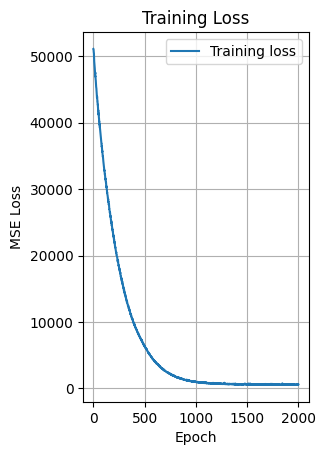

In [14]:
import matplotlib.pyplot as plt

# MSE Loss по епохах
plt.subplot(1,2,1)
plt.plot(losses, label='Training loss', color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

**Спостереження**

Графік показує, що втрата (MSE) стрімко зменшується - така динаміка означає, що модель успішно навчилася виявляти закономірність у часовому ряді.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [16]:
timeseries = data

In [18]:
def plot_predicts():

  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

RuntimeError: Input and parameter tensors are not at the same device, found input tensor at cpu and parameter tensor at cuda:0

In [19]:
def plot_predicts():
    model.eval()
    device = next(model.parameters()).device  # де лежать ваги моделі

    with torch.no_grad():
        # прогнози на device там де модель, потім повертаємо на CPU і в numpy
        train_pred = model(X_train.to(device)).squeeze(-1).cpu().numpy()  # shape: (train_size - lookback,)
        test_pred  = model(X_test.to(device)).squeeze(-1).cpu().numpy()   # shape: (len(data)-train_size-lookback,)

    # повний ряд реальних значень
    series = np.asarray(timeseries, dtype=np.float32)

    # заготовки під графік
    train_plot = np.full_like(series, np.nan, dtype=np.float32)
    test_plot  = np.full_like(series, np.nan, dtype=np.float32)

    # важливо: вирівнюємо індекси з вікном lookback
    train_plot[lookback:train_size] = train_pred
    test_plot[train_size + lookback: len(series)] = test_pred

    # візуалізація
    plt.figure(figsize=(10,4))
    plt.plot(series, label='Actual')
    plt.plot(train_plot, label='Train preds')
    plt.plot(test_plot, label='Test preds')
    plt.legend()
    plt.grid(True)
    plt.show()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

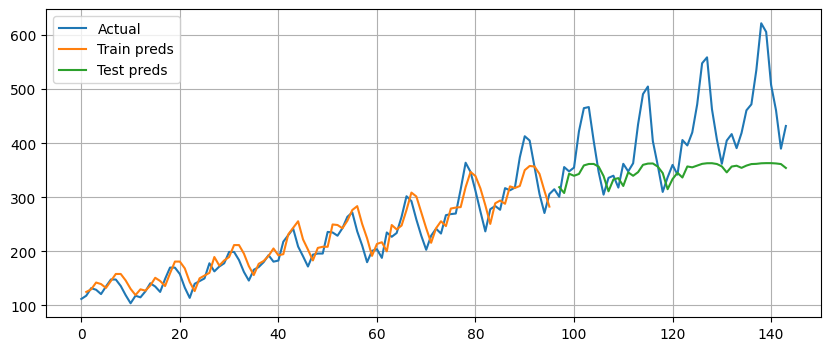

In [21]:
plot_predicts()

**Спостереження**

На тренувальній частині (помаранчева) - модель добре відтворює тренд і сезонність. Прогноз майже збігається з реальними значеннями, тобто LSTM навчилася відтворювати внутрішню структуру часового ряду.

На тестовій частині (зелена) - модель тримає загальний рівень (середнє значення), але втрачає сезонні коливання: піки і спади майже відсутні.
Це означає, що мережа вловила тренд, але не навчилася повністю узагальнювати періодичність на нових даних.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [22]:
# Знімаємо метрики і прогнози поточної моделі (hs=50)
model50 = model
model50.eval()
with torch.no_grad():
    tr_pred50 = model50(X_train.to(device))
    te_pred50 = model50(X_test.to(device))
    rmse_tr_50 = torch.sqrt(loss_fn(tr_pred50, y_train.to(device))).item()
    rmse_te_50 = torch.sqrt(loss_fn(te_pred50, y_test.to(device))).item()
tr_pred50_np = tr_pred50.squeeze(-1).cpu().numpy()
te_pred50_np = te_pred50.squeeze(-1).cpu().numpy()

print(f"[hs=50] train RMSE {rmse_tr_50:.4f}, test RMSE {rmse_te_50:.4f}")

[hs=50] train RMSE 24.4635, test RMSE 94.9542


In [23]:
# Модель hidden_size=100

model100 = AirModel(hidden_size=100, num_layers=1).to(device)
opt = torch.optim.Adam(model100.parameters(), lr=1e-3)

losses100 = []
train_rmse_list_100, test_rmse_list_100, epochs_to_plot = [], [], []

for epoch in range(epochs):
    model100.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()
        preds = model100(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())

    losses100.append(float(np.mean(batch_losses)))

    # лог кожні 100 епох у форматі з попередніх завдань
    if epoch % 100 == 0:
        model100.eval()
        with torch.no_grad():
            tr_pred = model100(X_train.to(device))
            te_pred = model100(X_test.to(device))
            rmse_tr = torch.sqrt(loss_fn(tr_pred, y_train.to(device))).item()
            rmse_te = torch.sqrt(loss_fn(te_pred, y_test.to(device))).item()
        train_rmse_list_100.append(rmse_tr)
        test_rmse_list_100.append(rmse_te)
        epochs_to_plot.append(epoch)
        print(f"Epoch {epoch}: train RMSE {rmse_tr:.4f}, test RMSE {rmse_te:.4f}")

Epoch 0: train RMSE 225.8944, test RMSE 422.3051
Epoch 100: train RMSE 144.7316, test RMSE 335.8094
Epoch 200: train RMSE 96.2647, test RMSE 276.6165
Epoch 300: train RMSE 67.2610, test RMSE 232.6130
Epoch 400: train RMSE 48.4115, test RMSE 196.3027
Epoch 500: train RMSE 36.4612, test RMSE 167.4071
Epoch 600: train RMSE 30.3516, test RMSE 145.3470
Epoch 700: train RMSE 26.8655, test RMSE 127.7557
Epoch 800: train RMSE 24.8950, test RMSE 116.0346
Epoch 900: train RMSE 24.3300, test RMSE 108.1872
Epoch 1000: train RMSE 23.7648, test RMSE 102.8912
Epoch 1100: train RMSE 26.9759, test RMSE 96.3717
Epoch 1200: train RMSE 25.3182, test RMSE 97.3978
Epoch 1300: train RMSE 23.3146, test RMSE 93.8929
Epoch 1400: train RMSE 23.3338, test RMSE 91.4814
Epoch 1500: train RMSE 22.9903, test RMSE 90.1554
Epoch 1600: train RMSE 24.8547, test RMSE 87.5164
Epoch 1700: train RMSE 22.9082, test RMSE 87.4477
Epoch 1800: train RMSE 23.8715, test RMSE 89.6693
Epoch 1900: train RMSE 23.6058, test RMSE 84.8503

In [24]:
# фінальні прогнози hs=100
model100.eval()
with torch.no_grad():
    tr_pred100 = model100(X_train.to(device))
    te_pred100 = model100(X_test.to(device))
    rmse_tr_100 = torch.sqrt(loss_fn(tr_pred100, y_train.to(device))).item()
    rmse_te_100 = torch.sqrt(loss_fn(te_pred100, y_test.to(device))).item()
tr_pred100_np = tr_pred100.squeeze(-1).cpu().numpy()
te_pred100_np = te_pred100.squeeze(-1).cpu().numpy()

print(f"[hs=100] train RMSE {rmse_tr_100:.4f}, test RMSE {rmse_te_100:.4f}")

[hs=100] train RMSE 23.0212, test RMSE 86.1338


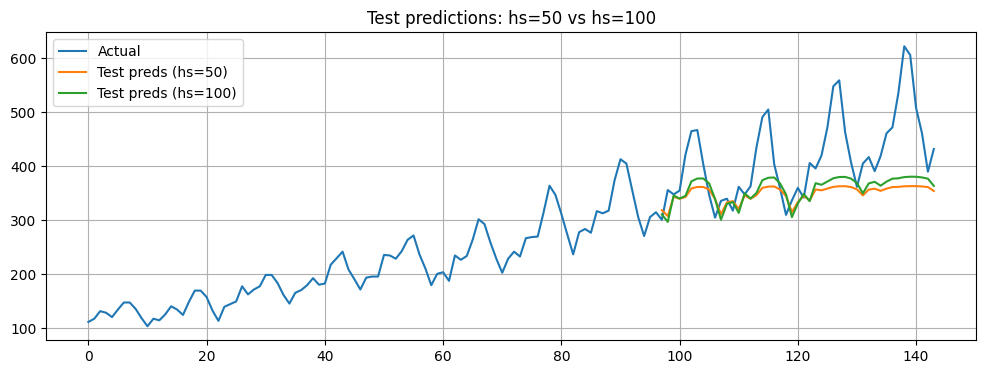

In [25]:
# Порівняльний графік (TEST)
series = np.asarray(timeseries, dtype=np.float32)
train_plot_50 = np.full_like(series, np.nan, dtype=np.float32)
test_plot_50  = np.full_like(series, np.nan, dtype=np.float32)
train_plot_100 = np.full_like(series, np.nan, dtype=np.float32)
test_plot_100  = np.full_like(series, np.nan, dtype=np.float32)

train_plot_50[lookback:train_size] = tr_pred50_np
test_plot_50[train_size+lookback:len(series)] = te_pred50_np
train_plot_100[lookback:train_size] = tr_pred100_np
test_plot_100[train_size+lookback:len(series)] = te_pred100_np

plt.figure(figsize=(12,4))
plt.plot(series, label='Actual')
plt.plot(test_plot_50,  label='Test preds (hs=50)')
plt.plot(test_plot_100, label='Test preds (hs=100)')
plt.legend(); plt.grid(True); plt.title('Test predictions: hs=50 vs hs=100')
plt.show()

**Висновок**

Збільшення hidden_size до 100 покращило якість прогнозів: модель трохи краще уловлює тренд і зменшує похибку.

Водночас надмірне збільшення прихованого шару не усуває головну проблему - втрата сезонності.

Ідеї для покращення:

- збільшити lookback (наприклад, до 12 місяців),

- або додати ще один LSTM-шар (num_layers=2),

- або провести нормалізацію даних перед тренуванням (MinMaxScaler).